# Three layer theory solver
Solves constrained-optimzation equations for three-layer networks.
It uses a two-step procedure. It first uses the iterative solver. 
If it does not converge, a running average is recorded. Then these
results are used as initial guesses for solving the self-consistent
equations.

When in the $\sigma_s>>\sigma_w$ regime, use `vary_values=np.linspace(0.1, 0.6, 30)`

### Parameter control

In [1]:
import numpy as np
default_sigw = 0.1
default_sigs = 1.2
vary_parameter = 'sigw'  #sigs or sigw
vary_values = np.linspace(0.1, 0.6, 30)

In [2]:
import matplotlib.pyplot as plt
import train_utils, torch, pickle, utils, model, copy, warnings, time
from tqdm import trange, tqdm
import response_utils as r_utils
import theory_utils as t_utils

%load_ext autoreload
%autoreload 2

parser = train_utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 100); parser.add('Nhid', 100); parser.add('n_layers', 3)

# task parameters
parser.add('sig_w', default_sigw)
parser.add('sig_s', default_sigs) # default value 0.2
parser.add('theta', np.pi)

# training parameter
parser.add('n_train_trials', 500)
parser.add('n_test_trials', 10000) 
parser.add('noise_var', .01)

args = parser.parse_args()

#%% USING a in-script solver (defined below)
average_if_not_converged = True

def predict_delw_threelayer(network:model.Model, stimuli, init_guess, update_coef, max_iter):
    """
    Solve the order parameter self-consistent equations for three-layer networks.
    """
    def norm_sq(x):
        return np.linalg.norm(x)**2

    x1 = stimuli.x1_normed.numpy().reshape(-1, 1)

    # create the effective weights
    w_effs, active_inds = r_utils.get_effective_weights(network, stimuli.x0); W1, W2, W3 = w_effs
    forward_mat = W3 @ W2 @ W1

    a = train_utils.mse_optimal_a(forward_mat, stimuli)
    
    a_norm_sq = np.linalg.norm(a)**2

    # Solve self-consistent equations by iterati\on
    def iteration_eqs(p):
        u1, u2, v1, v2 = p
        one_minus_v1_u2 = 1 - v1 * u2

        one_minus_a_norm_sq_v2 = 1 - a_norm_sq * v2

        Q1 = u1 * np.eye(W1.shape[1]) + one_minus_v1_u2**-1 * u2 * W1.T @ W1
        Q2 = one_minus_a_norm_sq_v2*np.eye(W2.shape[0])-a_norm_sq*one_minus_v1_u2**-1*v1*W2 @ W2.T

        invQ2 = np.linalg.inv(Q2)

        inv_mat = Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1
        _u, _s, _v = np.linalg.svd(inv_mat)
        # Lambda = np.linalg.inv(Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        Lambda = np.linalg.pinv(inv_mat, rcond=_s[3] / _s[0] - 0.01) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        U2 = invQ2 @ (W3.T @ a + a_norm_sq * one_minus_v1_u2**-1 * W2 @ W1 @ Lambda)
        
        u1_out = norm_sq(one_minus_v1_u2**-1 * (W2.T @ U2 + u2 * W1 @ Lambda))
        u2_out = norm_sq(U2)
        v1_out = norm_sq(Lambda)
        v2_out = norm_sq(one_minus_v1_u2**-1 * (W1 @ Lambda + v1 * W2.T @ U2))
        return np.array([u1_out, u2_out, v1_out, v2_out])
    
    # Declare op_vals a global variable, so that if the Python kernel is interrupted before predict_deltaw is complete, one can still access the trajectories of order parameters.
    global op_vals
    op_vals = [np.array(init_guess)]  # initial guesses for the order parameters

    for i in range(max_iter):
        new_vals = iteration_eqs(op_vals[-1])

        convergence_counter = 0
        for old_op, new_op in zip(op_vals[-1], new_vals):
            if np.abs(new_op - old_op) / np.abs(old_op) < 1e-2:
                convergence_counter += 1

        if i == 0:
            op_vals.append(update_coef * op_vals[-1] + (1-update_coef) * new_vals)
        else:
            op_vals.append(update_coef * op_vals[-1] + (1-update_coef) * new_vals)

        if convergence_counter == 4:
            print('===Converged===')
            break
        
        # Heuristic divergence fuse: if value exceeds some range, raise RuntimeError
        if op_vals[-1][0] > 100:
            raise RuntimeError('Divergence detected because u1>100.')
        if op_vals[-1][1] > 5000:
            raise RuntimeError('Divergence detected because u2>1000.')

        # dampen oscillations
        if (i + 1) % 1000 == 0:
            op_vals.append(np.mean(np.array(op_vals)[-1000:], axis=0))
            print(np.mean(np.array(op_vals)[-10:], axis=0))
    
    # if all iterations have been used, return an average
    if average_if_not_converged:
        if i == max_iter - 1:
            op_vals.append(np.mean(np.array(op_vals)[-10000:], axis=0))

    delW1, delW2, delW3 = t_utils.get_del_Ws_threelayer(*op_vals[-1], W1, W2, W3, a, a_norm_sq, x1)


    return np.array(op_vals), delW1, delW2, delW3, active_inds, a


ModuleNotFoundError: No module named 'train_utils'

## Iterate order parameter equations to get a rough estimate.
The initial guesses need to be adjusted for different parameter regimes

In [149]:
# init_init_guess = [10, 100, .00005, 0.00001]
# update_coef = 0.995
# max_iter = 10000

# for sigw=0.8, sigs=0.2
init_init_guess = [20, 140, .005, 0.0001]
update_coef = 0.995
max_iter = 2000
use_last_solution_as_guess = True

# init_init_guess = [20, 150, .004, 0.0002]
# update_coef = 0.999
# max_iter = 2000

# for sigs=0.2, sigw=0.6
# init_init_guess = [20, 170, .001, 0.0005]
# update_coef = 0.995
# max_iter = 10000

OPs_list = [] # store the trajectories of OPs to check for convergence
OPs = np.zeros((len(vary_values), 4))
delw1_list = []; delw2_list = []; delw3_list = []
active_inds_list = []
a_list = []
check_list = []

tic = time.time()

for i in range(len(vary_values)):

    print(f'{i+1}/{len(vary_values)}')
    if vary_parameter == 'sigs':
        args.sig_s = vary_values[i]
    elif vary_parameter == 'sigw':
        args.sig_w = vary_values[i]

    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)

    W_effs = r_utils.get_effective_weights(net, stimuli.x0)[0]

    # Use solutions for parameters in the last iteration as initial guesses
    if i == 0:
        init_guess = init_init_guess
    
    if use_last_solution_as_guess and i > 1:
        init_guess = OPs[i-1, :]

    _OPs, delw1, delw2, delw3, w_bounds, a = predict_delw_threelayer(net, stimuli, init_guess=init_guess, update_coef=update_coef, max_iter=max_iter)

    OPs[i, :] = _OPs[-1]
    OPs_list.append(_OPs)

    print([f'{num:.6f}' for num in _OPs[-1]])

    v_eff = (W_effs[0] + delw1).T @ (W_effs[1] + delw2).T @ (W_effs[2] + delw3).T @ a
    check_list.append(np.linalg.norm(v_eff - stimuli.x1_normed.numpy().T))

    print(f'x1 difference:{check_list[-1]:.3f}, time per run {int((time.time() - tic) / (i+1))}s')


    delw1_list.append(delw1); delw2_list.append(delw2); delw3_list.append(delw3)
    active_inds_list.append(w_bounds)
    a_list.append(a)



1/30
[1.54594222e+01 1.37588928e+02 5.73886306e-03 1.43532689e-04]
[1.22834380e+01 1.20125894e+02 5.67003280e-03 8.16084397e-05]
['14.776323', '130.775087', '0.005728', '0.000122']
x1 difference:0.095, time per run 5s
2/30
[1.77624277e+01 1.60063864e+02 4.93173087e-03 1.21310027e-04]
[1.30732635e+01 1.34094061e+02 5.78257204e-03 8.84529933e-05]
['16.170982', '148.296307', '0.005036', '0.000100']
x1 difference:0.069, time per run 5s
3/30
[1.49684595e+01 1.56677058e+02 4.93358579e-03 8.75179722e-05]
[1.40137643e+01 1.50082469e+02 5.13872737e-03 7.42745246e-05]
['17.471073', '168.892262', '0.004409', '0.000085']
x1 difference:0.078, time per run 5s
4/30
[1.61713473e+01 1.74880940e+02 4.40004804e-03 7.61677240e-05]
[1.48639984e+01 1.65769664e+02 4.62724793e-03 6.25870482e-05]
['18.365678', '185.795478', '0.003968', '0.000071']
x1 difference:0.078, time per run 5s
5/30
[1.71998128e+01 1.92052017e+02 3.98781673e-03 6.65569202e-05]
[1.52737591e+01 1.78842014e+02 4.26499515e-03 4.98819080e-05]

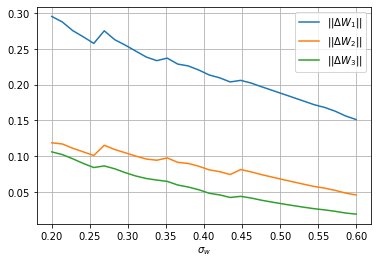

In [150]:
to_ind = 40

delw1_norms = [np.linalg.norm(mat) for mat in delw1_list]
delw2_norms = [np.linalg.norm(mat) for mat in delw2_list]
delw3_norms = [np.linalg.norm(mat) for mat in delw3_list]

plt.figure()
plt.plot(vary_values[:to_ind], delw1_norms, label='$||\Delta W_1||$')

plt.plot(vary_values[:to_ind], delw2_norms, label='$||\Delta W_2||$')
plt.plot(vary_values[:to_ind], delw3_norms, label='$||\Delta W_3||$')
# plt.ylim(-0.01, 0.5)
plt.xlabel('$\sigma_w$'); plt.legend(); plt.grid()




## Second step. Use outputs from the iterative solver as initial guesses for `fsolve`

In [155]:
from scipy.optimize import fsolve

args2 = copy.copy(args)


# model parameters
args2.N = 1000
args2.Nhid = 1000

def norm_sq(x):
    return np.linalg.norm(x)**2

fsolve_OPs = np.zeros((len(vary_values), 4))
fsolve_delw1_list = []; fsolve_delw2_list = []; fsolve_delw3_list = []
active_inds_list = []
a_list = []
check_list = []
fsolve_errors = []
x1_distances = []

tic = time.time()

for i in range(len(vary_values)):

    print(f'{i+1}/{len(vary_values)}')
    
    if vary_parameter == 'sigs':
        args2.sig_s = vary_values[i]
    elif vary_parameter == 'sigw':
        args2.sig_w = vary_values[i]
    net = model.Model(args2)
    stimuli = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    

    W_effs, active_inds = r_utils.get_effective_weights(net, stimuli.x0)
    W1, W2, W3 = W_effs
    x1 = stimuli.x1_normed.numpy().T
    F = W_effs[2] @ W_effs[1] @ W_effs[0]
    a = train_utils.mse_optimal_a(F, stimuli)
    a_list.append(a)
    a_norm_sq = np.linalg.norm(a)**2
    
    def self_consistent_eqs(p):
        u1, u2, v1, v2 = p
        one_minus_v1_u2 = 1 - v1 * u2
        one_minus_a_norm_sq_v2 = 1 - a_norm_sq * v2

        Q1 = u1 * np.eye(W1.shape[1]) + one_minus_v1_u2**-1 * u2 * W1.T @ W1
        Q2 = one_minus_a_norm_sq_v2*np.eye(W2.shape[0])-a_norm_sq*one_minus_v1_u2**-1*v1*W2 @ W2.T

        invQ2 = np.linalg.inv(Q2)

        inv_mat = Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1
        _u, _s, _v = np.linalg.svd(inv_mat)
        # Lambda = np.linalg.inv(Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1) @\
        (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        Lambda = np.linalg.inv(inv_mat) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        U2 = invQ2 @ (W3.T @ a + a_norm_sq * one_minus_v1_u2**-1 * W2 @ W1 @ Lambda)
        
        u1_out = norm_sq(one_minus_v1_u2**-1 * (W2.T @ U2 + u2 * W1 @ Lambda))
        u2_out = norm_sq(U2)
        v1_out = norm_sq(Lambda)
        v2_out = norm_sq(one_minus_v1_u2**-1 * (W1 @ Lambda + v1 * W2.T @ U2))
        return (u1_out - u1) / u1_out, (u2_out - u2) / u2_out, (v1_out - v1) / v1_out, (v2_out - v2) / v2_out

    fsolve_OP = fsolve(self_consistent_eqs, OPs[i], factor=0.5, maxfev=100000, xtol=1e-10)

    fsolve_OPs[i] = fsolve_OP

    # compute delW norms with fsolve parameters
    
    delW1, delW2, delW3 = t_utils.get_del_Ws_threelayer(*fsolve_OP, W1, W2, W3, a, a_norm_sq, x1)
    fsolve_delw1_list.append(delW1)
    fsolve_delw2_list.append(delW2)
    fsolve_delw3_list.append(delW3)
    x1_distances.append(np.linalg.norm(x1 - (W1 + delW1).T @ (W2 + delW2).T @ (W3 + delW3).T @ a))

    fsolve_errors.append(self_consistent_eqs(fsolve_OP))

    print([f'{num:.6f}' for num in fsolve_OP], 'Self-consistent Eq Errors:', [f'{num:.3e}' for num in fsolve_errors[-1]])

    # delw1_list.append(delw1); delw2_list.append(delw2); delw3_list.append(delw3)
    active_inds_list.append(active_inds)
    # a_list.append(a)


1/30
['16.278924', '134.935278', '0.005783', '0.000149'] Self-consistent Eq Errors: ['6.237e-07', '2.669e-07', '1.423e-07', '8.845e-07']
2/30
['17.054608', '148.416858', '0.005222', '0.000124'] Self-consistent Eq Errors: ['-1.346e-08', '3.131e-09', '-5.495e-08', '-2.190e-07']
3/30
['17.900327', '164.231574', '0.004680', '0.000101'] Self-consistent Eq Errors: ['-2.265e-08', '3.980e-08', '3.324e-08', '1.257e-08']
4/30
['18.468114', '176.371273', '0.004319', '0.000088'] Self-consistent Eq Errors: ['1.949e-05', '-1.336e-05', '2.437e-06', '1.769e-06']
5/30
['19.133916', '191.272978', '0.003941', '0.000074'] Self-consistent Eq Errors: ['3.882e-07', '-2.404e-07', '-3.613e-08', '2.906e-08']
6/30
['19.534600', '202.156166', '0.003688', '0.000066'] Self-consistent Eq Errors: ['1.901e-08', '-4.259e-08', '-3.849e-08', '-1.461e-08']
7/30
['20.018174', '215.558974', '0.003415', '0.000057'] Self-consistent Eq Errors: ['-4.839e-08', '4.175e-08', '1.956e-08', '2.858e-09']
8/30
['20.193067', '222.601662

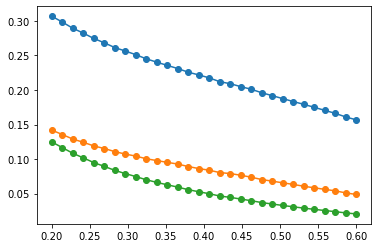

In [156]:
#%% Check results
plt.figure()
plt.plot(vary_values, [np.linalg.norm(_m) for _m in fsolve_delw1_list], marker='o')
plt.plot(vary_values, [np.linalg.norm(_m) for _m in fsolve_delw2_list], marker='o')
plt.plot(vary_values, [np.linalg.norm(_m) for _m in fsolve_delw3_list], marker='o')


## Save the results (maybe)

In [157]:
file_name = 'Saved Results/theory_3L_sigw0P8_vary_sigs'
pickle.dump({'delw1':fsolve_delw1_list, 'delw2':fsolve_delw2_list,
             'delw3':fsolve_delw3_list, 'OP':fsolve_OPs, 'a':a_list,
             'vary_values':vary_values, 'active_inds':active_inds_list, 'args':args, 'vary_parameter':vary_parameter}, open(file_name, 'wb'))
